In [1]:
import json

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [11]:
import json
file = "episodes_with_showdowns_clean_v2.json"
with open(file, 'r') as f:
    data = json.load(f)

In [24]:
wins = [0, 0, 0]
for i in range(len(data)):
    for j in range(len(data[i]['showcase_showdowns_structured'])):
        if data[i]['showcase_showdowns_structured'][j]['winner_computed'] is not None and data[i]['showcase_showdowns_structured'][j]['winner_computed'] >= 0 and data[i]['showcase_showdowns_structured'][j]['winner_computed'] <= 2:
            wins[data[i]['showcase_showdowns_structured'][j]['winner_computed']] += 1

In [26]:
wins /= np.sum(wins)
print(wins)

[0.31312435 0.3350844  0.35179125]


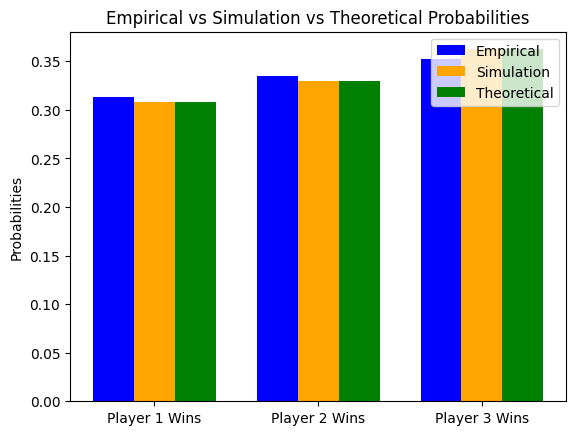

In [27]:
# Bar chart for 3 sets of three probabilities
empirical_data = wins
simulation_data = [963/3125, 3297231/10000000, 3621169/10000000]
theoretical_data = [6311/20480, 42188819/128000000, 46367431/128000000]
labels = ['Player 1 Wins', 'Player 2 Wins', 'Player 3 Wins']
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots()
bars1 = ax.bar(x - width, empirical_data, width, label='Empirical', color='blue')
bars2 = ax.bar(x, simulation_data, width, label='Simulation', color='orange')
bars3 = ax.bar(x + width, theoretical_data, width, label='Theoretical', color='green')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Probabilities')
ax.set_title('Empirical vs Simulation vs Theoretical Probabilities')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

In [29]:
theoretical_data

[0.308154296875, 0.3296001484375, 0.3622455546875]

In [36]:
p1 = pd.read_csv('data/optimal_policy/player1DP.csv')
p1 = p1[['Player1Spin', "WinProb1NoSpin", "WinProb1Spin", "PolicyDecision"]]
p1["Δpp"] = p1["WinProb1Spin"] - p1["WinProb1NoSpin"]
p1["PolicyDecision"] = p1["PolicyDecision"].map({0: "No Spin", 1: "Spin"})
p1["Player1Spin"] = 5 * p1["Player1Spin"]
p1

,Player1Spin,WinProb1NoSpin,WinProb1Spin,PolicyDecision,Δpp
0,5,0.000344,0.205947,Spin,0.205603
1,10,0.001215,0.205886,Spin,0.204671
2,15,0.002852,0.205743,Spin,0.202891
3,20,0.005397,0.205473,Spin,0.200076
4,25,0.009065,0.205020,Spin,0.195955
5,30,0.014146,0.204313,Spin,0.190167
6,35,0.021006,0.203263,Spin,0.182257
7,40,0.030086,0.201758,Spin,0.171672
8,45,0.041902,0.199663,Spin,0.157761
9,50,0.057044,0.196811,Spin,0.139767
